In [1]:
from script/helper import DATASETS, load_hsi_data, apply_pca, pad_with_zeros, create_patches
import os
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import spectral
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, cohen_kappa_score, classification_report

In [2]:
# Set hypeperameters and experimental settings just like the original code
RANDOM_SEED = 42
DATASET = 'IP'      # IP, UP, SA  
TRAIN_SIZE = 0.3    # ratio of training data
VAL_SIZE = 0.1      # ratio of valuating data
EPOCH = 100         # number of epoch
VAL_EPOCH = 5       # interval of valuation
LR = 0.001          # learning rate
WEIGHT_DECAY = 1e-6  
BATCH_SIZE = 256
DEVICE = 0          # -1:CPU  0:cuda 0
N_PCA = DATASETS[DATASET]["pca"]
class_name = DATASETS[DATASET]["class_name"]
NUM_CLASS = len(class_name)
PATCH_SIZE = 25
save_dir = Path("results") / DATASET
save_dir.mkdir(parents=True, exist_ok=True)

# Set random seed just like the original code
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
X, y = load_hsi_data(DATASET)

print(X.shape)  # e.g. (145, 145, 200)
print(y.shape)  # e.g. (145, 145)

Loading: /home/nith/projects/Recreate-Research-Paper/HybridSN Exploring 3D-2D CNN Feature Hierarchy for Hyperspectral Image Classification/data/IP/Indian_pines_corrected.mat
Loading: /home/nith/projects/Recreate-Research-Paper/HybridSN Exploring 3D-2D CNN Feature Hierarchy for Hyperspectral Image Classification/data/IP/Indian_pines_gt.mat
(145, 145, 200)
(145, 145)


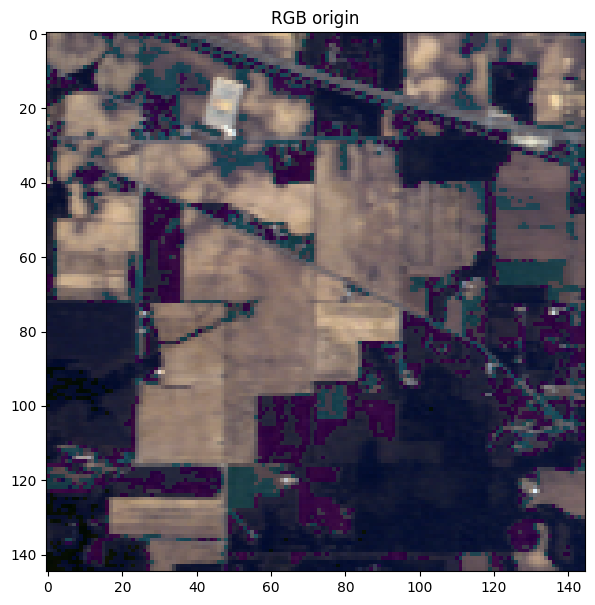

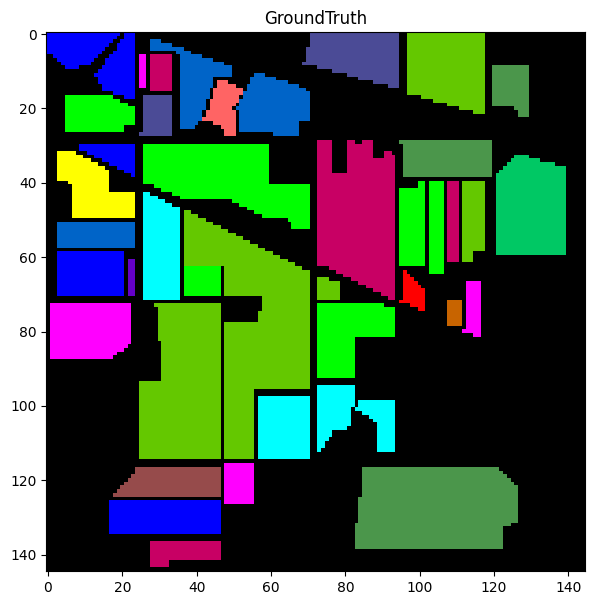

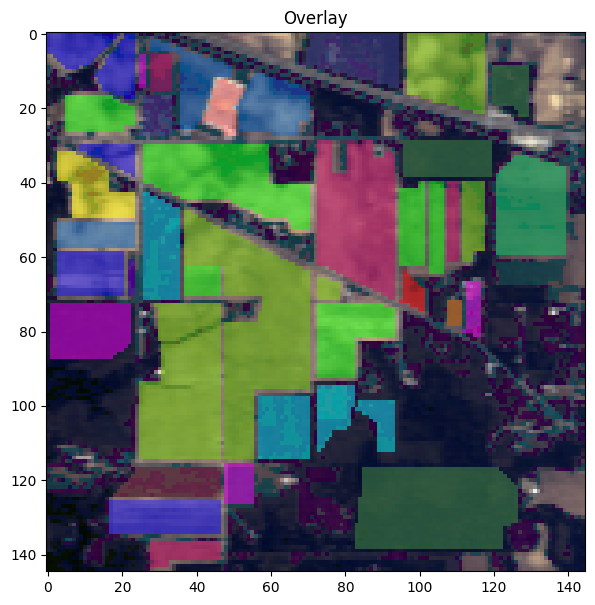

In [4]:
# Display HSI
# RGB
rgb_view = spectral.imshow(X, (30, 20, 10), classes=y, title="RGB origin", figsize=(7, 7))
rgb_view.set_display_mode("data")
#rgb_view.axes.figure.savefig(save_dir / f"{DATASET}_RGB_origin.jpg", bbox_inches="tight", dpi=300)

# Ground truth
gt_view = spectral.imshow(classes=y, title="GroundTruth", figsize=(7, 7))
#gt_view.axes.figure.savefig(save_dir / f"{DATASET}_gt.jpg", bbox_inches="tight", dpi=300)

# Overlay
view = spectral.imshow(X, (30, 20, 10), classes=y, figsize=(7, 7))
view.set_display_mode("overlay")
view.class_alpha = 0.5
view.set_title("Overlay")
#view.axes.figure.savefig(save_dir / f"{DATASET}_Overlay.jpg", bbox_inches="tight", dpi=300)

## Apply PCA

In [5]:
X_pca = apply_pca(X, n_components=DATASETS[DATASET]["pca"])
print(X_pca.shape)  # (145, 145, 30)

(145, 145, 30)


## Normalize the value

In [6]:
X_pca = X_pca.astype(np.float32)
mins = X_pca.min(axis=(0, 1), keepdims=True)
maxs = X_pca.max(axis=(0, 1), keepdims=True)
X_pca = (X_pca - mins) / (maxs - mins + 1e-8)

## Pad with zeros

In [7]:
margin = PATCH_SIZE // 2
X_pad = pad_with_zeros(X_pca, margin)

## Create samples

In [8]:
X_all, y_all = create_patches(X_pca, y, PATCH_SIZE)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_all
)

val_ratio_adjusted = VAL_SIZE / TRAIN_SIZE

X_val, X_train, y_val, y_train = train_test_split(
    X_temp, y_temp,
    train_size=val_ratio_adjusted,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

In [9]:
X_train.shape

(2050, 25, 25, 30)

In [10]:
def print_class_distribution(labels, class_name, title):
    counts = np.bincount(labels, minlength=len(class_name))
    total = counts.sum()

    print(f"\n{title}")
    for i, count in enumerate(counts):
        portion = count / total * 100
        print(f"{i:2d} | {class_name[i]:30s} | {count:5d} samples | {portion:6.2f}%")

print_class_distribution(y_all, class_name, "Full labeled dataset")
print_class_distribution(y_train, class_name, "Train set")
print_class_distribution(y_val, class_name, "Validation set")
print_class_distribution(y_test, class_name, "Test set")


Full labeled dataset
 0 | Alfalfa                        |    46 samples |   0.45%
 1 | Corn-notill                    |  1428 samples |  13.93%
 2 | Corn-mintill                   |   830 samples |   8.10%
 3 | Corn                           |   237 samples |   2.31%
 4 | Grass-pasture                  |   483 samples |   4.71%
 5 | Grass-trees                    |   730 samples |   7.12%
 6 | Grass-pasture-mowed            |    28 samples |   0.27%
 7 | Hay-windrowed                  |   478 samples |   4.66%
 8 | Oats                           |    20 samples |   0.20%
 9 | Soybean-notill                 |   972 samples |   9.48%
10 | Soybean-mintill                |  2455 samples |  23.95%
11 | Soybean-clean                  |   593 samples |   5.79%
12 | Wheat                          |   205 samples |   2.00%
13 | Woods                          |  1265 samples |  12.34%
14 | Buildings-Grass-Trees-Drives   |   386 samples |   3.77%
15 | Stone-Steel-Towers             |    93 samp

### Reshape for HybridSN input

In [11]:
X_train = np.transpose(X_train, (0, 3, 1, 2))
X_val   = np.transpose(X_val,   (0, 3, 1, 2))
X_test  = np.transpose(X_test,  (0, 3, 1, 2))

X_train = X_train[:, np.newaxis, :, :, :]
X_val   = X_val[:, np.newaxis, :, :, :]
X_test  = X_test[:, np.newaxis, :, :, :]

In [12]:
X_train.shape

(2050, 1, 30, 25, 25)

## Build Dataset and DataLoader

In [13]:
class HSIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
train_loader = DataLoader(HSIDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(HSIDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(HSIDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## Implement the HybridSN model

In [15]:
class HybridSN(nn.Module):
    def __init__(self, num_classes: int, num_bands: int = 30, patch_size: int = 25, dropout: float = 0.4):
        super().__init__()

        self.num_classes = num_classes
        self.num_bands = num_bands
        self.patch_size = patch_size

        # Input: (N, 1, Bands, Patch, Patch)
        self.conv3d_1 = nn.Sequential(
            nn.Conv3d(in_channels=1, out_channels=8, kernel_size=(7, 3, 3)),
            nn.ReLU(inplace=True),
        )

        self.conv3d_2 = nn.Sequential(
            nn.Conv3d(in_channels=8, out_channels=16, kernel_size=(5, 3, 3)),
            nn.ReLU(inplace=True),
        )
        
        self.conv3d_3 = nn.Sequential(
            nn.Conv3d(in_channels=16, out_channels=32, kernel_size=(3, 3, 3)),
            nn.ReLU(inplace=True),
        )

        # We infer the 2D conv input size dynamically, so this work for 30 PCA bands
        # and also for 15-band setups
        self.con2d_in_channels, self.flatten_dim = self._infer_shapes(num_bands, patch_size)

        self.conv2d_1 = nn.Sequential(
            nn.Conv2d(in_channels=self.con2d_in_channels, out_channels=64, kernel_size=3),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes),
        )

    def _forward_features(self, x: torch.Tensor) -> torch.Tensor:
        # x: (N, 1, Bands, Patch, Patch)
        x = self.conv3d_1(x)  # (N, 8, 24, 23, 23) for 30 bands / 25 patch
        x = self.conv3d_2(x)  # (N, 16, 20, 21, 21)
        x = self.conv3d_3(x)  # (N, 32, 18, 19, 19)

        # Merge spectral-depth and channel dims for 2D conv:
        # (N, 32, D, H, W) -> (N, 32*D, H, W)
        n, c, d, h, w = x.shape
        x = x.reshape(n, c * d, h, w)  # (N, 576, 19, 19)
        x = self.conv2d_1(x)  # (N, 64, 17, 17)
        x = x.reshape(x.size(0), -1)  # (N, 18496) for 30 bands / 25x25 setup
        return x

    def _infer_shapes(self, num_bands: int, patch_size: int):
        with torch.no_grad():
            dummy = torch.zeros(1, 1, num_bands, patch_size, patch_size)
            x = self.conv3d_1(dummy)
            x = self.conv3d_2(x)
            x = self.conv3d_3(x)
            _, c, d, h, w = x.shape
            conv2d_in_channels = c * d

            x = x. reshape(1, conv2d_in_channels, h, w)
            x = nn.Conv2d(conv2d_in_channels, 64, kernel_size=3)(x)
            flatten_dim = x.numel()

        return conv2d_in_channels, flatten_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._forward_features(x)
        x = self.classifier(x)
        return x

In [16]:
net = HybridSN(NUM_CLASS, N_PCA, PATCH_SIZE)

summary(
    net,
    input_size=(1, 1, N_PCA, PATCH_SIZE, PATCH_SIZE),  # batch, channel, bands, H, W
    col_names=("num_params", "kernel_size", "mult_adds", "input_size", "output_size"),
    col_width=14,
    row_settings=("var_names",),
    depth=4,
)

Layer (type (var_name))                  Param #        Kernel Shape   Mult-Adds      Input Shape    Output Shape
HybridSN (HybridSN)                      --             --             --             [1, 1, 30, 25, 25] [1, 16]
├─Sequential (conv3d_1)                  --             --             --             [1, 1, 30, 25, 25] [1, 8, 24, 23, 23]
│    └─Conv3d (0)                        512            [7, 3, 3]      6,500,352      [1, 1, 30, 25, 25] [1, 8, 24, 23, 23]
│    └─ReLU (1)                          --             --             --             [1, 8, 24, 23, 23] [1, 8, 24, 23, 23]
├─Sequential (conv3d_2)                  --             --             --             [1, 8, 24, 23, 23] [1, 16, 20, 21, 21]
│    └─Conv3d (0)                        5,776          [5, 3, 3]      50,944,320     [1, 8, 24, 23, 23] [1, 16, 20, 21, 21]
│    └─ReLU (1)                          --             --             --             [1, 16, 20, 21, 21] [1, 16, 20, 21, 21]
├─Sequential (conv3d_3)  

### Single iteration

In [17]:
device = torch.device(f"cuda:{DEVICE}" if DEVICE >= 0 and torch.cuda.is_available() else "cpu")

num_classes = len(DATASETS[DATASET]["class_name"])
model = HybridSN(
    num_classes=num_classes,
    num_bands=N_PCA,
    patch_size=PATCH_SIZE,
    dropout=0.4,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Get one batch
xb, yb = next(iter(train_loader))

print("before move:")
print("xb:", xb.shape, xb.dtype)
print("yb:", yb.shape, yb.dtype)

xb = xb.to(device)
yb = yb.to(device)

model.train()
optimizer.zero_grad()

out = model(xb)

print("model output:", out.shape)   # should be (batch_size, num_classes)

loss = criterion(out, yb)
print("loss:", loss.item())

loss.backward()
optimizer.step()

print("Single iteration passed.")

before move:
xb: torch.Size([256, 1, 30, 25, 25]) torch.float32
yb: torch.Size([256]) torch.int64
model output: torch.Size([256, 16])
loss: 2.779974937438965
Single iteration passed.


In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        out = model(xb)
        loss = criterion(out, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [19]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        out = model(xb)
        loss = criterion(out, yb)

        running_loss += loss.item() * xb.size(0)

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        #print("true :", yb)
        #print("pred :", preds)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [20]:
best_val_acc = 0.0
best_model_path = save_dir / "best_model.pth"

for epoch in range(1, EPOCH + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    print(
        f"Epoch [{epoch:03d}/{EPOCH}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}"
    )

    if epoch % VAL_EPOCH == 0:
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        print(
            f"                 "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model to {best_model_path}")

Epoch [001/100] Train Loss: 2.4919 | Train Acc: 0.2263
Epoch [002/100] Train Loss: 2.5059 | Train Acc: 0.1712
Epoch [003/100] Train Loss: 2.4235 | Train Acc: 0.1766
Epoch [004/100] Train Loss: 2.4515 | Train Acc: 0.2283
Epoch [005/100] Train Loss: 2.3804 | Train Acc: 0.2341
                 Val Loss: 2.3349 | Val Acc: 0.2393
Saved best model to results/IP/best_model.pth
Epoch [006/100] Train Loss: 2.3803 | Train Acc: 0.2322
Epoch [007/100] Train Loss: 2.3540 | Train Acc: 0.2312
Epoch [008/100] Train Loss: 2.2557 | Train Acc: 0.2561
Epoch [009/100] Train Loss: 2.2140 | Train Acc: 0.2600
Epoch [010/100] Train Loss: 2.2047 | Train Acc: 0.2556
                 Val Loss: 2.0817 | Val Acc: 0.2861
Saved best model to results/IP/best_model.pth
Epoch [011/100] Train Loss: 2.1024 | Train Acc: 0.2800
Epoch [012/100] Train Loss: 2.3859 | Train Acc: 0.2068
Epoch [013/100] Train Loss: 2.2631 | Train Acc: 0.2673
Epoch [014/100] Train Loss: 2.1336 | Train Acc: 0.2805
Epoch [015/100] Train Loss: 2.0196

## Evaluate

Test Loss: 0.0341 | Test Acc: 0.9907


100%|█████████████████████████████| 41/41 [00:00<00:00, 55.57it/s]


num predicted patches: 10249
num labeled pixels: 10249


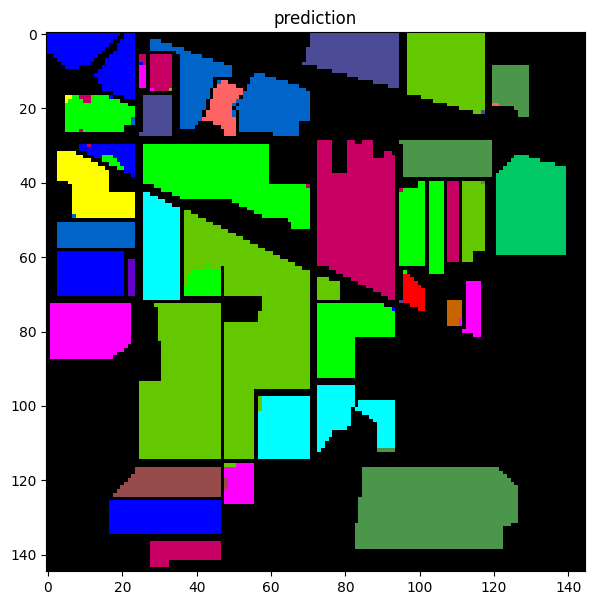

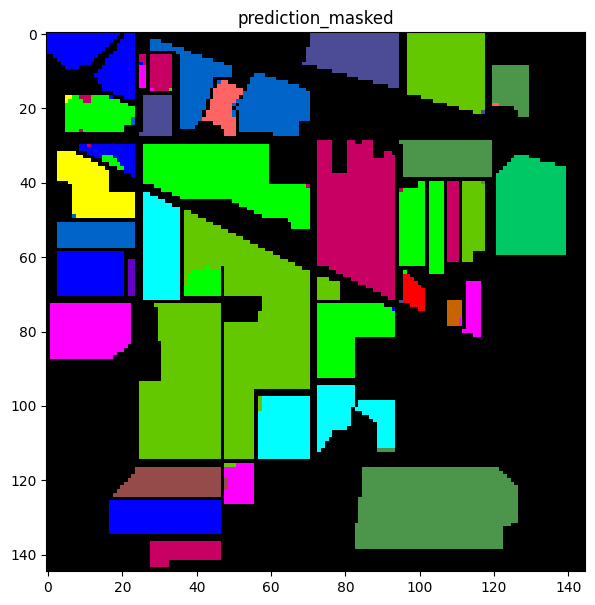

In [21]:
from tqdm import tqdm

model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

pred_list = []

all_loader = DataLoader(
    HSIDataset(X_all, y_all),
    batch_size=BATCH_SIZE,
    shuffle=False
)

with torch.no_grad():
    for x, _ in tqdm(all_loader, total=len(all_loader)):
        x = x.permute(0, 3, 1, 2).unsqueeze(1).float().to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        pred_list.append(pred.cpu().numpy() + 1)   # back to 1..NUM_CLASS

pred_flat = np.hstack(pred_list).astype(np.uint8)

print("num predicted patches:", len(pred_flat))
print("num labeled pixels:", np.sum(y != 0))

pred_map = np.zeros_like(y, dtype=np.uint8)
pred_map[y != 0] = pred_flat

# same as pred_map here, since background is already 0
pred_map_masked = pred_map.copy()

spectral.imshow(classes=pred_map, title="prediction", figsize=(7, 7))
spectral.imshow(classes=pred_map_masked, title="prediction_masked", figsize=(7, 7))

spectral.save_rgb(
    os.path.join(save_dir, f"{DATASET}_prediction.jpg"),
    pred_map,
    colors=spectral.spy_colors
)

spectral.save_rgb(
    os.path.join(save_dir, f"{DATASET}_prediction_masked.jpg"),
    pred_map_masked,
    colors=spectral.spy_colors
)

In [22]:
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_preds = []
    all_true = []

    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        all_preds.append(preds)
        all_true.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)
    return y_true, y_pred

test_true, test_pred = predict_loader(model, test_loader, device)

OA = accuracy_score(test_true, test_pred)
AA = recall_score(test_true, test_pred, average="macro")
kappa = cohen_kappa_score(test_true, test_pred)

report_log = f"OA: {OA:.4f}\nAA: {AA:.4f}\nKappa: {kappa:.4f}\n"
report_log += classification_report(
    test_true,
    test_pred,
    labels=np.arange(NUM_CLASS),
    target_names=class_name,
    digits=4
)

print(report_log)

with open(os.path.join(save_dir, "classification_report_test.txt"), "w") as fp:
    fp.write(report_log)

OA: 0.9907
AA: 0.9788
Kappa: 0.9893
                              precision    recall  f1-score   support

                     Alfalfa     1.0000    0.9375    0.9677        32
                 Corn-notill     0.9899    0.9760    0.9829      1000
                Corn-mintill     0.9965    0.9828    0.9896       581
                        Corn     0.9821    0.9940    0.9880       166
               Grass-pasture     0.9909    0.9704    0.9806       338
                 Grass-trees     1.0000    0.9824    0.9911       511
         Grass-pasture-mowed     1.0000    0.9000    0.9474        20
               Hay-windrowed     1.0000    1.0000    1.0000       335
                        Oats     1.0000    1.0000    1.0000        14
              Soybean-notill     0.9812    0.9971    0.9891       680
             Soybean-mintill     0.9896    0.9994    0.9945      1719
               Soybean-clean     0.9811    1.0000    0.9905       415
                       Wheat     0.9862    1.0000    

## Save the model

In [ ]:
best_model_path = save_dir / f"{DATASET}best_model.pth"